# Import libraries

In [1]:
# standard library
import os
import re
import sys
import subprocess
import importlib.util
import random

# third-party
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.regressionplots import plot_partregress
import joblib

# local imports
from scripts.helpers import map_to_color
from scripts.lower_dim import compute_pcs

from helper.io import load_data
from helper.geno import per_genotype_freq_per_human
from helper.pheno import make_pheno
from helper.plotting import show_biases

# Load data

In [2]:
raw_geno, humans = load_data()

# Standardize

In [3]:
majaf, hetaf, minaf = per_genotype_freq_per_human(raw_geno, pop=humans["populations"])
majaf_tot = majaf.mean() 
hetaf_tot = hetaf.mean()
minaf_tot = minaf.mean()
geno_std = raw_geno - (majaf_tot-minaf_tot)
geno_std =geno_std/hetaf_tot**0.5
geno_corr_std = raw_geno - (majaf-minaf)
geno_corr_std = geno_corr_std/hetaf_tot**0.5

# Create population bias

In [4]:
pheno = make_pheno(humans)

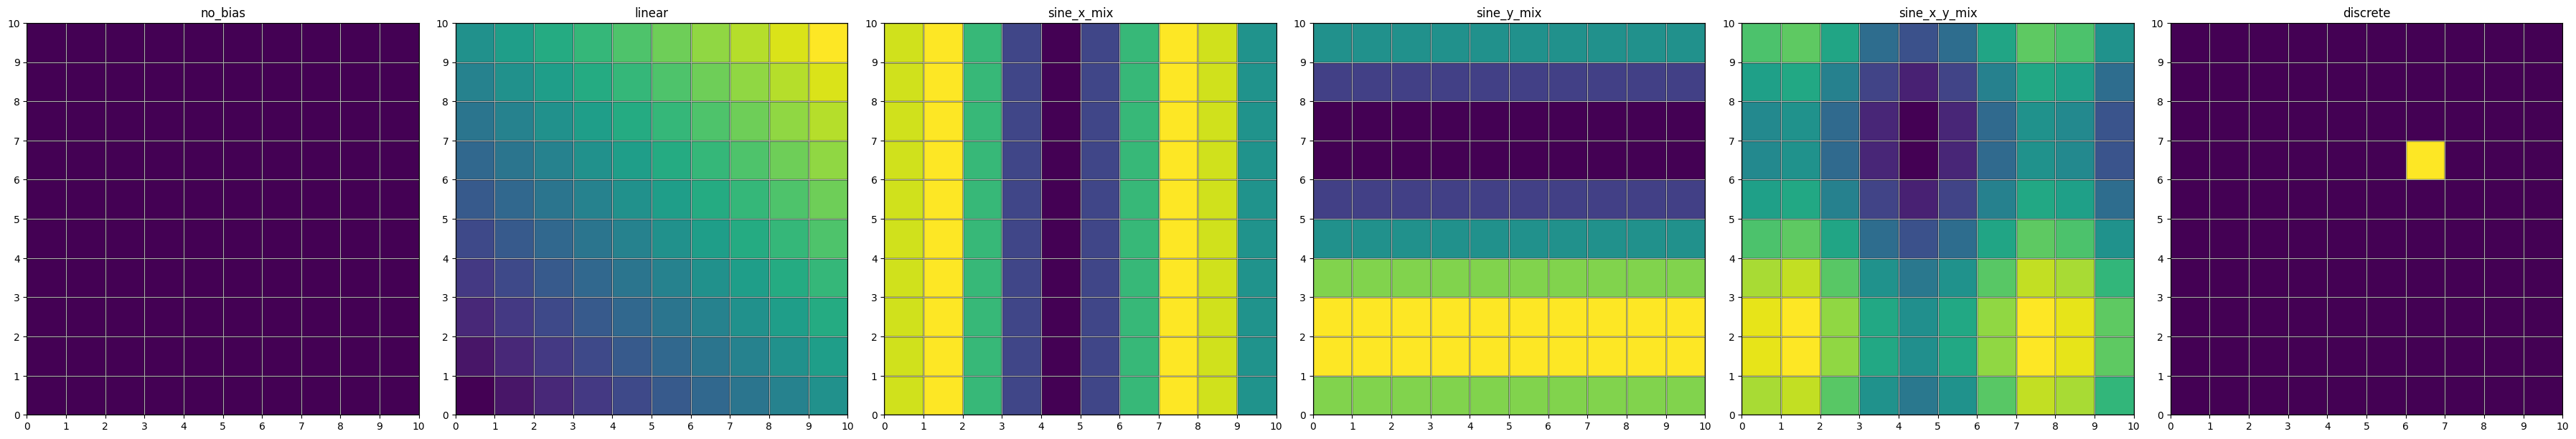

In [5]:
show_biases(pheno)

In [6]:
chosen_bias = "discrete"
pheno[chosen_bias] = (pheno[chosen_bias] - pheno[chosen_bias].mean()) / pheno[chosen_bias].std()

In [7]:
def fit_line(x_, y_):
    slope, intercept, r, p, se = stats.linregress(x_, y_)
    neglogp = -np.log10(p) if p > 0 else np.inf
    return slope, intercept, neglogp
    
def find_most_associated_snp(geno, pheno):
    snps = []
    slopes = []
    neglogps = []
    for snp in geno.columns:
        slope, intercept, neglogp = fit_line(geno[snp], pheno)
        snps.append(snp)
        slopes.append(slope)
        neglogps.append(neglogp)
    

In [8]:
find_most_associated_snp(geno_std, pheno[chosen_bias])

C_1_MAF_0.500
C_2_MAF_0.500
C_3_MAF_0.500
C_4_MAF_0.500
C_5_MAF_0.500
C_6_MAF_0.500
C_7_MAF_0.499
C_8_MAF_0.499
C_9_MAF_0.499
C_10_MAF_0.499
C_11_MAF_0.498
C_12_MAF_0.498
C_13_MAF_0.498
C_14_MAF_0.498
C_15_MAF_0.497
C_16_MAF_0.497
C_17_MAF_0.497
C_18_MAF_0.497
C_19_MAF_0.497
C_20_MAF_0.497
C_21_MAF_0.497
C_22_MAF_0.497
C_23_MAF_0.497
C_24_MAF_0.496
C_25_MAF_0.496
C_26_MAF_0.496
C_27_MAF_0.496
C_28_MAF_0.496
C_29_MAF_0.496
C_30_MAF_0.496
C_31_MAF_0.496
C_32_MAF_0.496
C_33_MAF_0.496
C_34_MAF_0.495
C_35_MAF_0.495
C_36_MAF_0.495
C_37_MAF_0.495
C_38_MAF_0.495
C_39_MAF_0.495
C_40_MAF_0.495
C_41_MAF_0.495
C_42_MAF_0.495
C_43_MAF_0.495
C_44_MAF_0.494
C_45_MAF_0.494
C_46_MAF_0.494
C_47_MAF_0.494
C_48_MAF_0.494
C_49_MAF_0.493
C_50_MAF_0.493
C_51_MAF_0.493
C_52_MAF_0.493
C_53_MAF_0.492
C_54_MAF_0.492
C_55_MAF_0.492
C_56_MAF_0.491
C_57_MAF_0.491
C_58_MAF_0.491
C_59_MAF_0.491
C_60_MAF_0.490
C_61_MAF_0.490
C_62_MAF_0.490
C_63_MAF_0.489
C_64_MAF_0.489
C_65_MAF_0.489
C_66_MAF_0.489
C_67_MAF_0.489
C_68